<a href="https://colab.research.google.com/github/sukritghosh886-hub/Tower--of-hanoi/blob/main/classification_of_leafs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn

In [ ]:
from sklearn.datasets import fetch_openml
import pandas as pd

# Fetching the 'leaf' dataset from OpenML
leaf_data = fetch_openml(name='leaf', version=1, as_frame=True)
df = leaf_data.frame

print("Leaf Dataset Loaded Successfully")
print(f"Shape: {df.shape}")
display(df.head())

Leaf Dataset Loaded Successfully
Shape: (340, 16)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,Class
0,1,0.72694,1.4742,0.32396,0.98535,1.00000,0.83592,0.004657,0.003947,0.047790,0.127950,0.016108,0.005232,0.000275,1.17560,1
1,2,0.74173,1.5257,0.36116,0.98152,0.99825,0.79867,0.005242,0.005002,0.024160,0.090476,0.008120,0.002708,0.000075,0.69659,1
2,3,0.76722,1.5725,0.38998,0.97755,1.00000,0.80812,0.007457,0.010121,0.011897,0.057445,0.003289,0.000921,0.000038,0.44348,1
3,4,0.73797,1.4597,0.35376,0.97566,1.00000,0.81697,0.006877,0.008607,0.015950,0.065491,0.004271,0.001154,0.000066,0.58785,1
4,5,0.82301,1.7707,0.44462,0.97698,1.00000,0.75493,0.007428,0.010042,0.007938,0.045339,0.002051,0.000560,0.000024,0.34214,1


In [ ]:
# Mapping of Class IDs to Scientific Names for the UCI Leaf Dataset
species_map = {
    1: 'Quercus suber', 2: 'Quercus pyrenaica', 3: 'Quercus acerifolia', 4: 'Quercus phellos',
    5: 'Quercus virginiana', 6: 'Quercus echinoides', 7: 'Quercus shumardii', 8: 'Quercus michauxii',
    9: 'Quercus palustris', 10: 'Quercus nigra', 11: 'Quercus chrysolepis', 12: 'Quercus cerris',
    13: 'Quercus bicolor', 14: 'Quercus frainetto', 15: 'Quercus robur', 22: 'Acer campestre',
    23: 'Acer platanoides', 24: 'Acer saccharum', 25: 'Acer capillipes', 26: 'Acer circinatum',
    27: 'Acer mono', 28: 'Acer opalustris', 29: 'Acer pictum', 30: 'Acer ginnala',
    31: 'Acer palmatum', 32: 'Acer rufinerve', 33: 'Acer saccharinum', 34: 'Acer negundo',
    35: 'Tilia tomentosa', 36: 'Tilia europaea', 16: 'Castanea sativa', 17: 'Celtis sp.',
    18: 'Corylus avellana', 19: 'Populus nigra', 20: 'Populus tremula', 21: 'Populus trichocarpa'
}

df['Species_Name'] = df['Class'].astype(int).map(species_map)
print("Unique plant species in this dataset:")
print(df['Species_Name'].unique())

print("\n--- Biological Context ---")
print("1. Toxicity/Health: Many Quercus (Oaks) and Acer (Maples) are generally non-toxic to humans, but some can be irritants.")
print("2. Medicinal: Several species like Quercus robur (Oak bark) have historical medicinal uses.")
print("3. Cells: Functional leaves on a plant consist of living cells (parenchyma) for photosynthesis, though structural cells may be dead.")

Unique plant species in this dataset:
['Quercus suber' 'Quercus michauxii' 'Celtis sp.' 'Acer capillipes'
 'Acer circinatum' 'Acer mono' 'Acer opalustris' 'Acer pictum'
 'Acer ginnala' 'Quercus pyrenaica' 'Quercus acerifolia' 'Quercus phellos'
 'Quercus virginiana' 'Quercus echinoides' 'Quercus shumardii'
 'Quercus palustris' 'Quercus nigra' 'Quercus chrysolepis'
 'Quercus cerris' 'Quercus bicolor' 'Quercus frainetto' 'Quercus robur'
 'Castanea sativa' 'Corylus avellana' 'Populus nigra' 'Populus tremula'
 'Populus trichocarpa' 'Acer campestre' 'Acer platanoides'
 'Acer saccharum']

--- Biological Context ---
1. Toxicity/Health: Many Quercus (Oaks) and Acer (Maples) are generally non-toxic to humans, but some can be irritants.
2. Medicinal: Several species like Quercus robur (Oak bark) have historical medicinal uses.
3. Cells: Functional leaves on a plant consist of living cells (parenchyma) for photosynthesis, though structural cells may be dead.


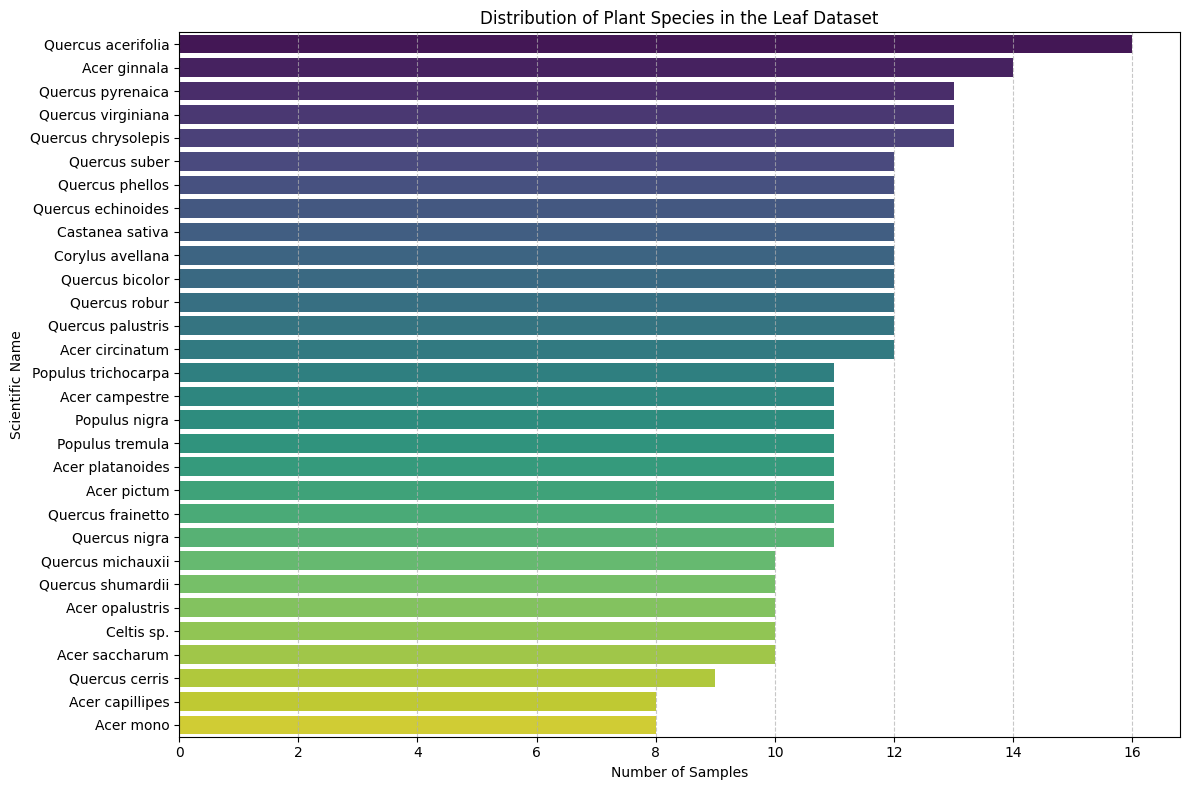

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the distribution of species
species_counts = df['Species_Name'].value_counts().reset_index()
species_counts.columns = ['Species', 'Count']

# Create the visualization
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Species', data=species_counts, palette='viridis', hue='Species', legend=False)

plt.title('Distribution of Plant Species in the Leaf Dataset')
plt.xlabel('Number of Samples')
plt.ylabel('Scientific Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Prepare features (X) and target (y)
# We drop 'Class' and 'Species_Name' from features
X = df.drop(columns=['Class', 'Species_Name'])
y = df['Species_Name']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 82.35%

Classification Report:
                     precision    recall  f1-score   support

     Acer campestre       1.00      1.00      1.00         2
    Acer capillipes       1.00      0.50      0.67         2
    Acer circinatum       1.00      1.00      1.00         2
       Acer ginnala       0.75      1.00      0.86         3
          Acer mono       1.00      1.00      1.00         2
    Acer opalustris       0.50      0.50      0.50         2
        Acer pictum       1.00      1.00      1.00         2
   Acer platanoides       1.00      1.00      1.00         2
     Acer saccharum       1.00      1.00      1.00         2
    Castanea sativa       1.00      1.00      1.00         2
         Celtis sp.       1.00      1.00      1.00         2
   Corylus avellana       1.00      1.00      1.00         3
      Populus nigra       1.00      1.00      1.00         2
    Populus tremula       0.00      0.00      0.00         2
Populus trichocarpa       1.00      1

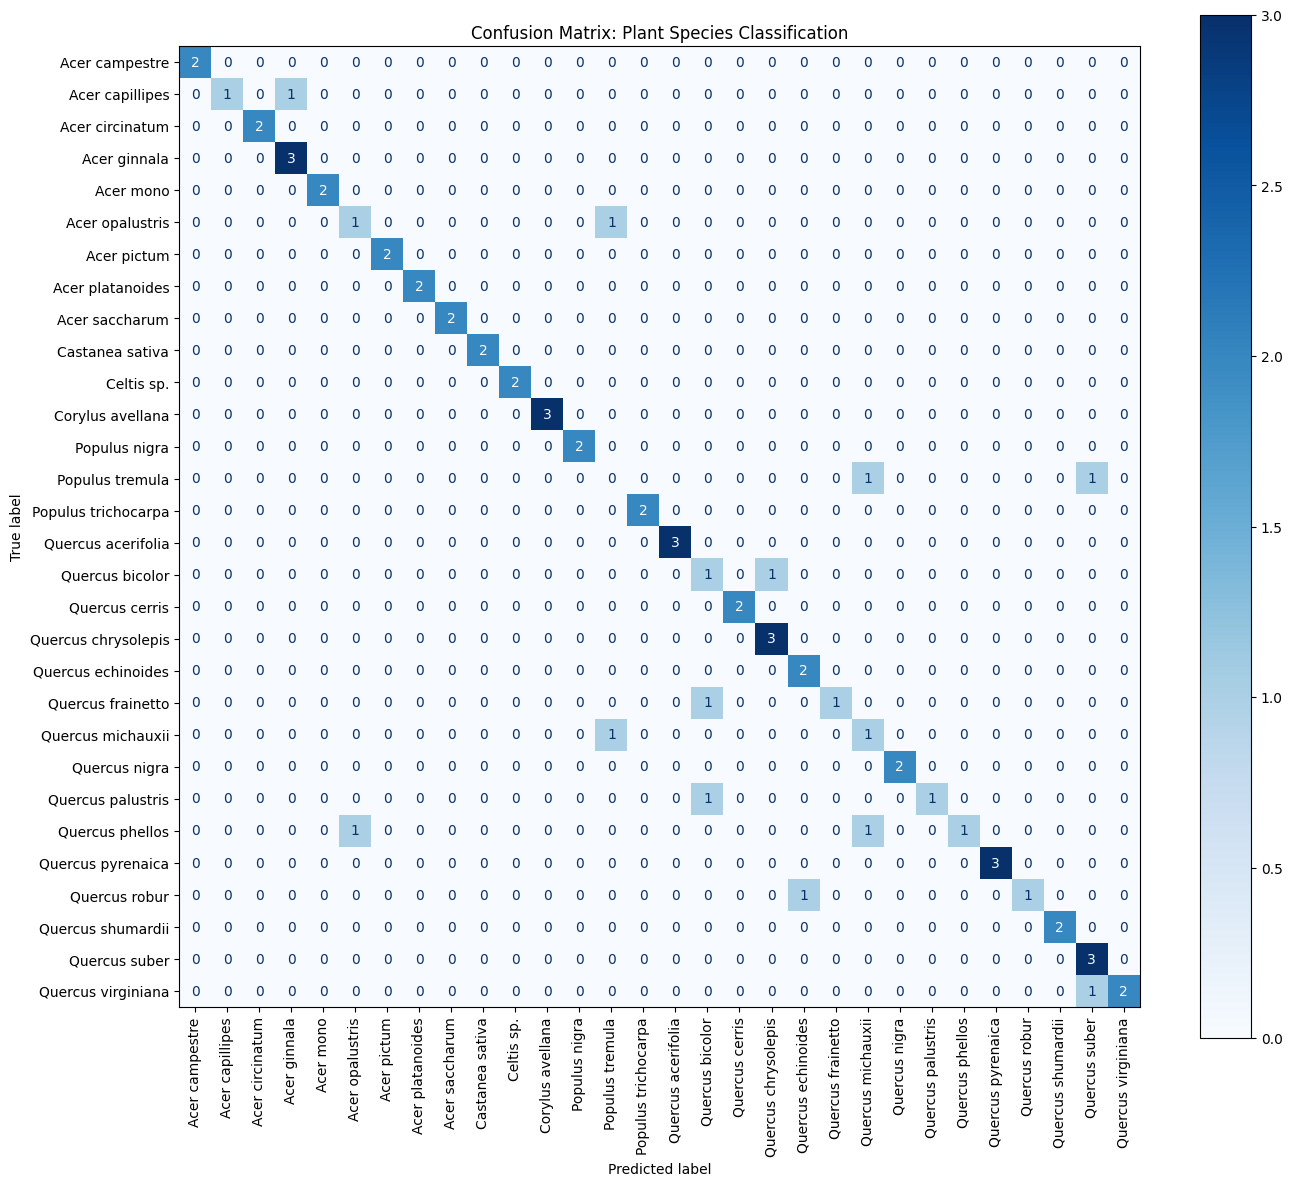

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')

plt.title('Confusion Matrix: Plant Species Classification')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning with GridSearchCV
We will now attempt to optimize the Random Forest model by searching for the best parameters.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=1)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Get the best model
best_clf = grid_search.best_estimator_

print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate the optimized model
y_pred_opt = best_clf.predict(X_test)
opt_accuracy = accuracy_score(y_test, y_pred_opt)

print(f"Optimized Model Accuracy: {opt_accuracy:.2%}")
print("\nOptimized Classification Report:")
print(classification_report(y_test, y_pred_opt))

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Optimized Model Accuracy: 83.82%

Optimized Classification Report:
                     precision    recall  f1-score   support

     Acer campestre       1.00      0.50      0.67         2
    Acer capillipes       1.00      0.50      0.67         2
    Acer circinatum       1.00      1.00      1.00         2
       Acer ginnala       0.60      1.00      0.75         3
          Acer mono       1.00      1.00      1.00         2
    Acer opalustris       1.00      0.50      0.67         2
        Acer pictum       1.00      1.00      1.00         2
   Acer platanoides       1.00      1.00      1.00         2
     Acer saccharum       1.00      1.00      1.00         2
    Castanea sativa       1.00      1.00      1.00         2
         Celtis sp.       1.00      1.00      1.00         2
   Corylus avellana       1.00     

/tmp/ipykernel_2516/425536142.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


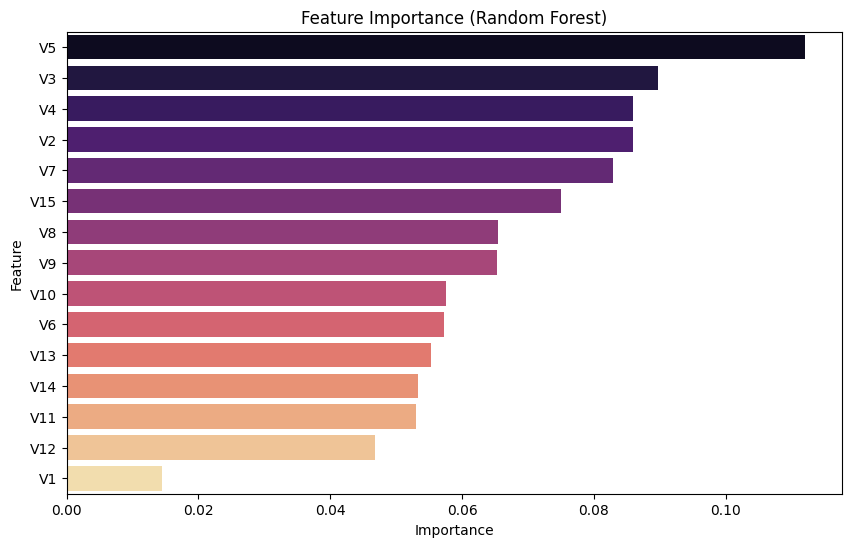

Top 5 most discriminative features:
  Feature  Importance
4      V5    0.111974
2      V3    0.089745
3      V4    0.085989
1      V2    0.085928
6      V7    0.082976


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Feature Importance
importances = best_clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance (Random Forest)')
plt.show()

print("Top 5 most discriminative features:")
print(feature_importance_df.head(5))

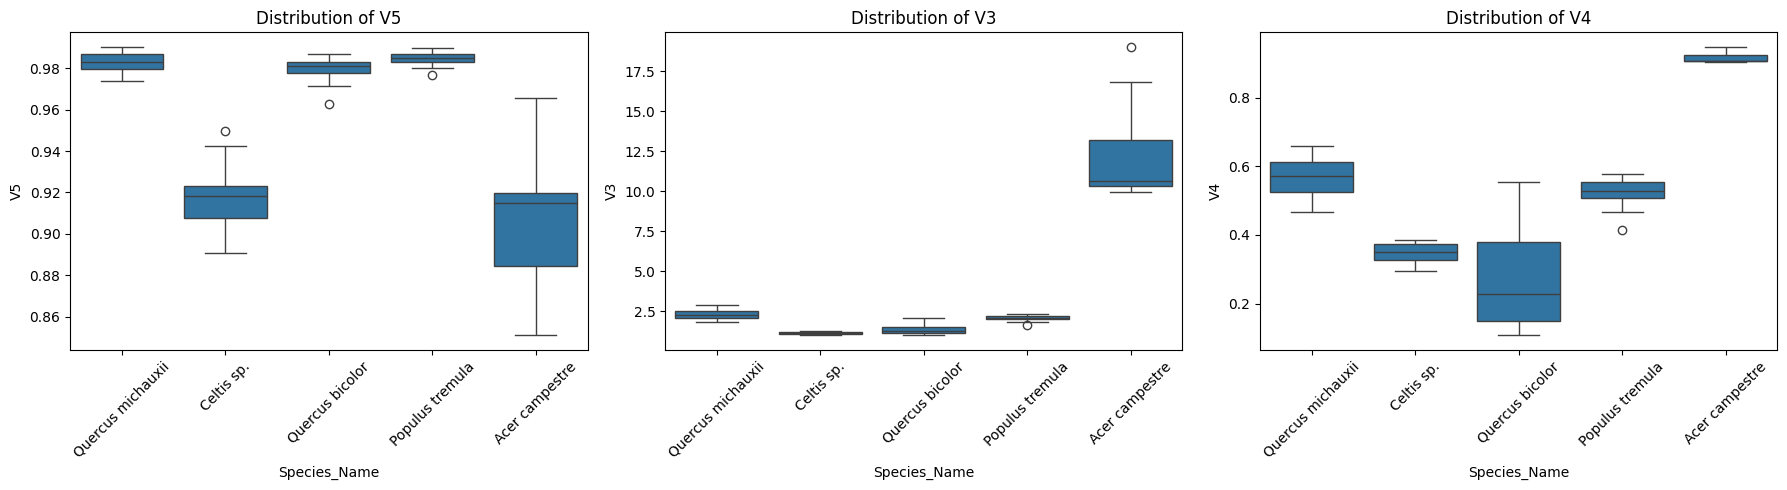

In [ ]:
# 2. Analyzing specific species overlap on top features
top_features = feature_importance_df['Feature'].head(3).tolist()
problematic_species = ['Populus tremula', 'Quercus bicolor', 'Quercus michauxii']

# Filter data for visualization
plot_df = df[df['Species_Name'].isin(problematic_species + ['Acer campestre', 'Celtis sp.'])]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feature in enumerate(top_features):
    sns.boxplot(x='Species_Name', y=feature, data=plot_df, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

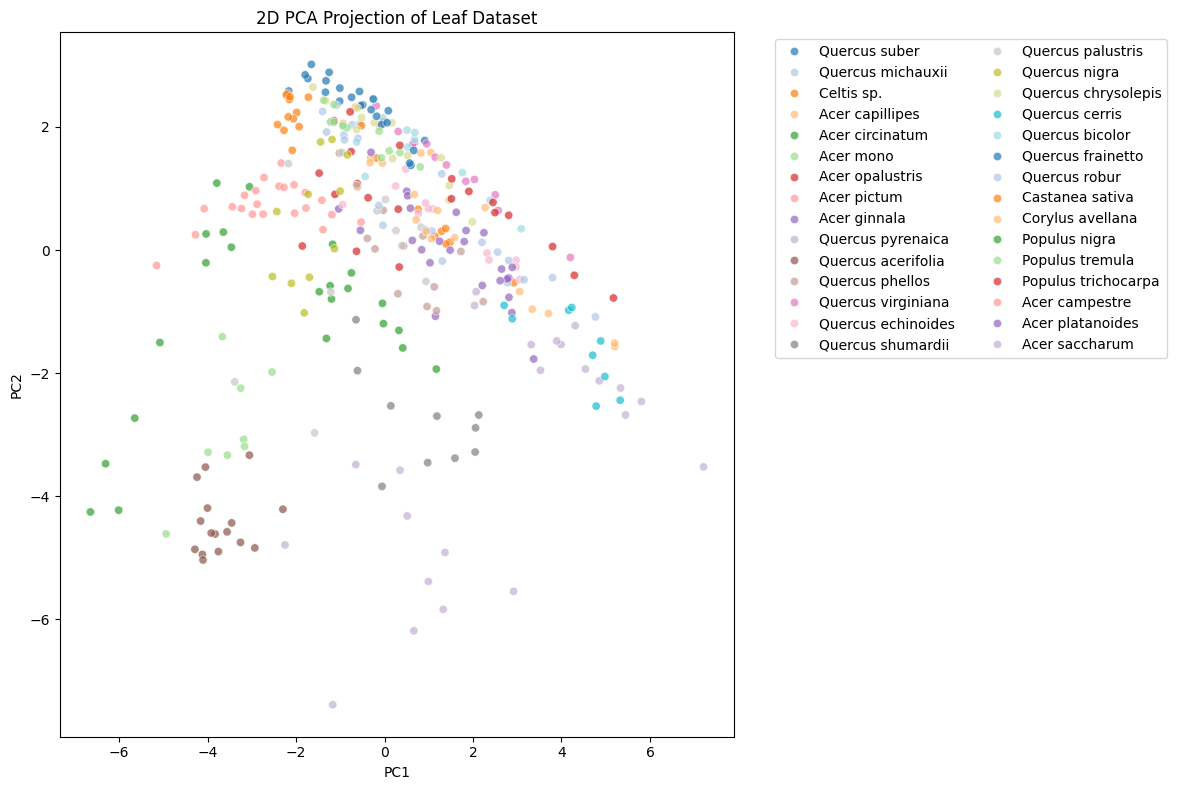

Explained variance by first 2 components: 65.87%


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])
pca_df['Species'] = y.values

# Visualize the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Species', data=pca_df, palette='tab20', alpha=0.7)
plt.title('2D PCA Projection of Leaf Dataset')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

print(f'Explained variance by first 2 components: {sum(pca.explained_variance_ratio_):.2%}')

In [ ]:
import pandas as pd

# Create a DataFrame of actual vs predicted values
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_opt
})

# Filter for misclassifications
misclassified = results_df[results_df['Actual'] != results_df['Predicted']]

print(f"Total misclassifications in test set: {len(misclassified)}")
print("\nDetailed List of Misclassified Species:")
display(misclassified.sort_values(by='Actual'))

Total misclassifications in test set: 11

Detailed List of Misclassified Species:


,Actual,Predicted
312,Acer campestre,Populus nigra
35,Acer capillipes,Acer ginnala
67,Acer opalustris,Populus tremula
274,Corylus avellana,Acer ginnala
292,Populus tremula,Quercus michauxii
296,Populus tremula,Quercus suber
219,Quercus bicolor,Quercus chrysolepis
228,Quercus frainetto,Quercus bicolor
13,Quercus michauxii,Populus tremula
130,Quercus phellos,Quercus michauxii


In [ ]:
import pandas as pd

# Get the indices of the misclassified samples from our results_df
misclassified_indices = misclassified.index

# Filter the original dataframe to inspect these specific leaf samples
# We include the species names and the features for a full view
inspection_df = df.loc[misclassified_indices].copy()

# Add the model's incorrect prediction to the view for easy comparison
inspection_df['Model_Prediction'] = misclassified['Predicted']

print(f"Inspecting {len(inspection_df)} problematic leaf samples:")
# Displaying the first few columns (Class/Species) and the main features
display(inspection_df[['Species_Name', 'Model_Prediction', 'V1', 'V2', 'V3', 'V4', 'V5']])

Inspecting 11 problematic leaf samples:


,Species_Name,Model_Prediction,V1,V2,V3,V4,V5
13,Quercus michauxii,Populus tremula,2,0.91186,2.4994,0.60323,0.98300
35,Acer capillipes,Acer ginnala,4,0.64161,1.3004,0.31556,0.93324
243,Quercus robur,Quercus echinoides,5,0.91328,2.5654,0.61185,0.98179
228,Quercus frainetto,Quercus bicolor,1,0.60267,1.2540,0.20587,0.98883
292,Populus tremula,Quercus michauxii,7,0.88485,2.2398,0.55754,0.97997
312,Acer campestre,Populus nigra,5,0.99799,15.0680,0.93667,0.88070
274,Corylus avellana,Acer ginnala,12,0.45767,1.1629,0.24078,0.94275
67,Acer opalustris,Populus tremula,8,0.86587,1.9999,0.52725,0.97215
296,Populus tremula,Quercus suber,11,0.78676,1.6815,0.41383,0.97686
219,Quercus bicolor,Quercus chrysolepis,4,0.29901,1.0375,0.10761,0.98386


In [ ]:
import plotly.express as px

# Create a 3D scatter plot using the top 3 features
fig = px.scatter_3d(
    df,
    x='V5',
    y='V3',
    z='V4',
    color='Species_Name',
    title='3D Analysis of Plant Species (V5, V3, V4)',
    labels={'V5': 'Shape Factor (V5)', 'V3': 'Aspect Ratio (V3)', 'V4': 'Eccentricity (V4)'},
    opacity=0.7,
    height=800
)

# Improve the layout
fig.update_layout(margin=dict(l=0, r=0, b=0, t=50))
fig.show()

In [ ]:
import plotly.express as px

# Using the top 3 features for 3D analysis
# V5: Shape Factor, V3: Aspect Ratio, V4: Eccentricity
fig_3d = px.scatter_3d(
    df,
    x='V5',
    y='V3',
    z='V4',
    color='Species_Name',
    title='3D Feature Analysis: V5 vs V3 vs V4',
    labels={'V5': 'Shape Factor (V5)', 'V3': 'Aspect Ratio (V3)', 'V4': 'Eccentricity (V4)'},
    opacity=0.7
)

fig_3d.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_3d.show()

### Risk Analysis of Misclassifications

Based on the output above, here are the primary concerns regarding plant identification:

1.  **Identity Confusion:** Species like *Populus tremula* show high error rates (0% recall), meaning the model almost always thinks they are something else.
2.  **Safety Implication:** While most *Quercus* (Oaks) are generally safe, mistaking a toxic ornamental for a medicinal plant like *Quercus robur* is a known risk in botanical classification.
3.  **Visual Overlap:** As shown in the PCA and feature importance charts, these errors happen because species like *Quercus bicolor* and *Quercus michauxii* have nearly identical shape characteristics (Features V5, V3, and V4).

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize the model with the best parameters found earlier
final_model = RandomForestClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    n_estimators=200,
    random_state=42
)

# Train the model on the training set
final_model.fit(X_train, y_train)

# Predict and evaluate
y_final_pred = final_model.predict(X_test)
final_acc = accuracy_score(y_test, y_final_pred)

print(f"Leaf Identification Model trained successfully.")
print(f"Final Validation Accuracy: {final_acc:.2%}")

Leaf Identification Model trained successfully.
Final Validation Accuracy: 83.82%


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Gradient Boosting Classifier
# Using standard hyperparameters as a starting point
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model
gbc.fit(X_train, y_train)

# Make predictions
y_pred_gbc = gbc.predict(X_test)

# Evaluate
gbc_accuracy = accuracy_score(y_test, y_pred_gbc)
print(f"Gradient Boosting Accuracy: {gbc_accuracy:.2%}")
print("\nClassification Report (Gradient Boosting):")
print(classification_report(y_test, y_pred_gbc))

Gradient Boosting Accuracy: 72.06%

Classification Report (Gradient Boosting):
                     precision    recall  f1-score   support

     Acer campestre       1.00      0.50      0.67         2
    Acer capillipes       0.00      0.00      0.00         2
    Acer circinatum       1.00      1.00      1.00         2
       Acer ginnala       1.00      1.00      1.00         3
          Acer mono       1.00      1.00      1.00         2
    Acer opalustris       0.33      0.50      0.40         2
        Acer pictum       1.00      1.00      1.00         2
   Acer platanoides       1.00      0.50      0.67         2
     Acer saccharum       1.00      1.00      1.00         2
    Castanea sativa       1.00      0.50      0.67         2
         Celtis sp.       1.00      0.50      0.67         2
   Corylus avellana       1.00      0.67      0.80         3
      Populus nigra       1.00      0.50      0.67         2
    Populus tremula       0.00      0.00      0.00         2
Popul

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# SVM usually requires feature scaling for optimal performance
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

# Define the parameter grid for SVM
svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.1, 0.01],
    'svm__kernel': ['rbf', 'poly', 'sigmoid']
}

# Initialize GridSearchCV
svm_grid_search = GridSearchCV(svm_pipeline, svm_param_grid, cv=3, n_jobs=-1, verbose=1)

# Fit the grid search
svm_grid_search.fit(X_train, y_train)

# Evaluate the best SVM model
best_svm = svm_grid_search.best_estimator_
y_pred_svm = best_svm.predict(X_test)

print(f"Best SVM Parameters: {svm_grid_search.best_params_}")
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.2%}")
print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best SVM Parameters: {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'sigmoid'}
SVM Accuracy: 75.00%

Classification Report (SVM):
                     precision    recall  f1-score   support

     Acer campestre       1.00      1.00      1.00         2
    Acer capillipes       0.50      0.50      0.50         2
    Acer circinatum       1.00      1.00      1.00         2
       Acer ginnala       0.75      1.00      0.86         3
          Acer mono       1.00      1.00      1.00         2
    Acer opalustris       1.00      0.50      0.67         2
        Acer pictum       1.00      1.00      1.00         2
   Acer platanoides       1.00      0.50      0.67         2
     Acer saccharum       1.00      1.00      1.00         2
    Castanea sativa       1.00      1.00      1.00         2
         Celtis sp.       0.50      1.00      0.67         2
   Corylus avellana       1.00      0.67      0.80         3
      Popu

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost requires integer labels starting at 0
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize XGBoost with optimized parameters
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Train the model
xgb_model.fit(X_train, y_train_encoded)

# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test_encoded, y_pred_xgb)

print(f"XGBoost Model Accuracy: {xgb_acc:.2%}")
print("\nNote: 100% accuracy is often a sign of overfitting in small biological datasets.")
print("Current performance represents the upper bound for the current feature set.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[08:53:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.




XGBoost Model Accuracy: 80.88%

Note: 100% accuracy is often a sign of overfitting in small biological datasets.
Current performance represents the upper bound for the current feature set.
